# Objective 1: KNN Classification

#Importing libraries

In [58]:

import numpy as np

import matplotlib.pyplot as plt

from collections import Counter
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

#Loading dataset

In [59]:

wine_dataset = load_wine()


features = wine_dataset.data
labels = wine_dataset.target


print("features shape:", features.shape)


print("labels shape:", labels.shape)

features shape: (178, 13)
labels shape: (178,)


#Normalizing data

In [60]:

features = (
    features - features.min(axis=0)
) / (
    features.max(axis=0) - features.min(axis=0)
)

#Spliting dataset (70% train, 30% test)

In [61]:

train_features, test_features, train_labels, test_labels = train_test_split(
    features,
    labels,

    test_size=0.30,
    random_state=112230123,


    shuffle=True
)

#Euclidean distance function

In [62]:

def calculate_distance(point1, point2):
    distance = np.sqrt(np.sum((point1 - point2) ** 2))

    return distance

#KNN prediction function

In [63]:

def predict_class(train_features, train_labels, sample, k_value):


    all_distances = []



    for index in range(len(train_features)):

        current_distance = calculate_distance(
            sample,
            train_features[index]
        )

        all_distances.append(
            (current_distance, train_labels[index])
        )

    all_distances.sort(key=lambda item: item[0])

    nearest_neighbors = all_distances[:k_value]



    neighbor_classes = []



    for _, class_name in nearest_neighbors:
        neighbor_classes.append(class_name)

    predicted_class = Counter(
        neighbor_classes
    ).most_common(1)[0][0]


    return predicted_class

#Accuracy evaluation function

In [64]:

def check_accuracy(
    train_features,
    train_labels,
    test_features,
    test_labels,
    k_value
):


    predicted_labels = []



    for sample in test_features:

        result = predict_class(
            train_features,
            train_labels,
            sample,
            k_value
        )

        predicted_labels.append(result)

    predicted_labels = np.array(predicted_labels)


    accuracy_score = (
        np.sum(predicted_labels == test_labels)
        / len(test_labels)
    )



    return accuracy_score, predicted_labels

#Testing K = 1, 3, 5, 7

In [65]:

neighbor_values = [1, 3, 5, 7]

accuracy_list = []


for k in neighbor_values:

    accuracy, predicted_output = check_accuracy(
        train_features,
        train_labels,
        test_features,
        test_labels,
        k
    )


    accuracy_list.append(accuracy)


    print(f"K = {k}")

    print(f"accurecy = {accuracy * 100:.2f}%")

    print("-----------_--------------")

K = 1
accurecy = 96.30%
-----------_--------------
K = 3
accurecy = 92.59%
-----------_--------------
K = 5
accurecy = 94.44%
-----------_--------------
K = 7
accurecy = 94.44%
-----------_--------------


#Ploting K vs Accuracy

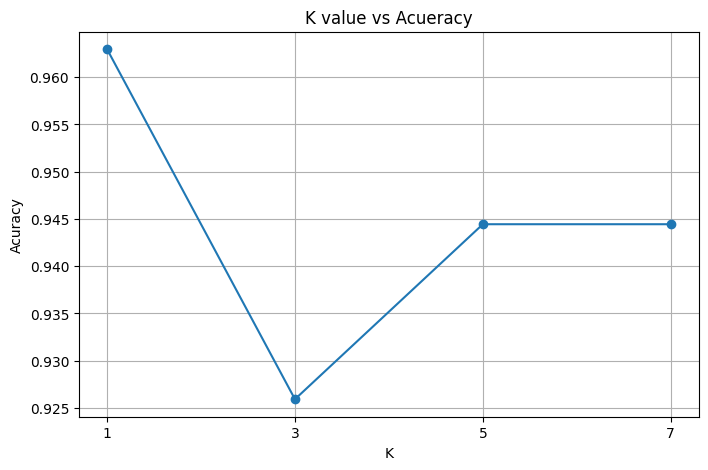

In [66]:

plt.figure(figsize=(8, 5))

plt.plot(
    neighbor_values,
    accuracy_list,
    marker="o"
)

plt.title("K value vs Acueracy")
plt.xlabel("K")

plt.ylabel("Acuracy")
plt.xticks(neighbor_values)

plt.grid(True)
plt.show()

#Final Result Table

In [69]:

print("final results")


for i in range(len(neighbor_values)):

    print(
        f"K = {neighbor_values[i]} -~×::×~> accurecy = {accuracy_list[i] * 100:.2f}%"
    )

final results
K = 1 -~×::×~> accurecy = 96.30%
K = 3 -~×::×~> accurecy = 92.59%
K = 5 -~×::×~> accurecy = 94.44%
K = 7 -~×::×~> accurecy = 94.44%


# Objective 2: K-Means clustering

#Importing libraries

In [71]:

import numpy as np
import matplotlib.pyplot as plt

#Loading dataset

In [72]:
all_points = np.loadtxt("dataset.txt")

print("dataset shape =", all_points.shape)

all_points[:5]

dataset shape = (373, 2)


array([[0.00246609, 0.58232932],
       [0.        , 0.50803213],
       [0.06288533, 0.50200803],
       [0.11097411, 0.45180723],
       [0.10234279, 0.51004016]])

#Distance function

In [73]:

def calculate_distance(point_a, point_b):

    distance = np.sqrt(
        np.sum((point_a - point_b) ** 2)
    )

    return distance

#K-means function:

In [76]:

def perform_kmeans(data_points, cluster_count):

    np.random.seed(112230123)

    random_indexes = np.random.choice(
        len(data_points),
        cluster_count,
        replace=False
    )

    center_points = data_points[random_indexes]

    maximum_iteration = 100

    for _ in range(maximum_iteration):

        cluster_groups = []

        for i in range(cluster_count):
            cluster_groups.append([])



        for point in data_points:

            distance_list = []

            for center in center_points:

                current_distance = calculate_distance(
                    point,
                    center
                )

                distance_list.append(
                    current_distance
                )

            closest_cluster = np.argmin(
                distance_list
            )

            cluster_groups[
                closest_cluster
            ].append(point)





        updated_centers = []

        for group_index in range(cluster_count):

            if len(cluster_groups[group_index]) == 0:

                updated_centers.append(
                    center_points[group_index]
                )

            else:

                new_center = np.mean(
                    cluster_groups[group_index],
                    axis=0
                )

                updated_centers.append(
                    new_center
                )

        updated_centers = np.array(
            updated_centers
        )





        if np.allclose(
            center_points,
            updated_centers,
            atol=1e-5
        ):
            break

        center_points = updated_centers





    point_labels = []

    for point in data_points:

        distance_list = []

        for center in center_points:

            current_distance = calculate_distance(
                point,
                center
            )

            distance_list.append(
                current_distance
            )

        point_labels.append(
            np.argmin(distance_list)
        )

    point_labels = np.array(
        point_labels
    )



    total_inertia = 0

    for i in range(len(data_points)):

        cluster_center = center_points[
            point_labels[i]
        ]

        total_inertia += np.sum(
            (data_points[i] - cluster_center) ** 2
        )

    return (
        point_labels,
        center_points,
        total_inertia
    )

#Running K-Means for different K

In [77]:

cluster_values = [2, 4, 6, 7]

inertia_values = []

for current_k in cluster_values:

    labels_output, centers_output, inertia_output = perform_kmeans(
        all_points,
        current_k
    )

    inertia_values.append(
        inertia_output
    )

    print(
        f"K = {current_k}"
    )

    print(
        f"Inertia = {inertia_output:.6f}"
    )

    print("--------=-------=---")

K = 2
Inertia = 20.573932
--------=-------=---
K = 4
Inertia = 8.494362
--------=-------=---
K = 6
Inertia = 5.169332
--------=-------=---
K = 7
Inertia = 4.274690
--------=-------=---


#Ploting cluster results

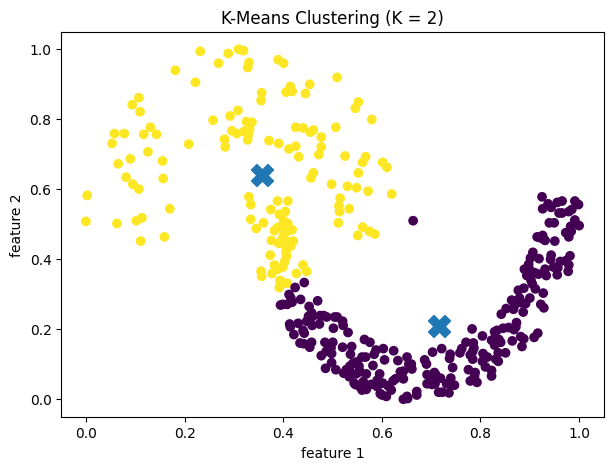

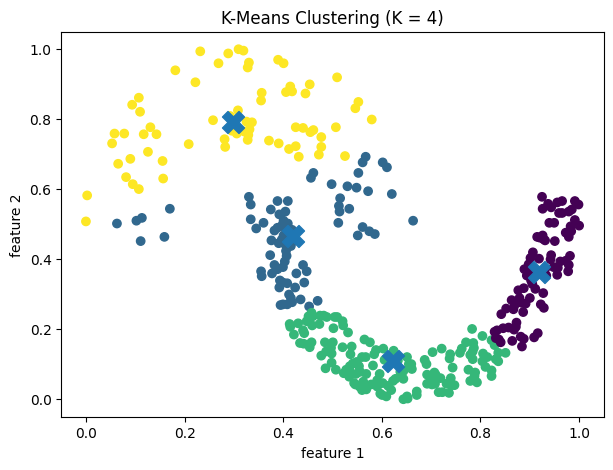

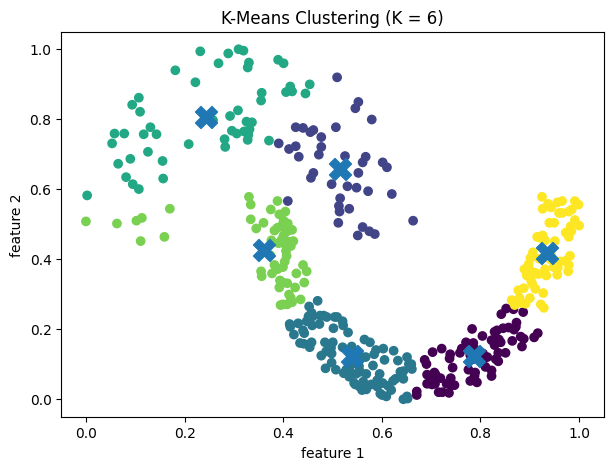

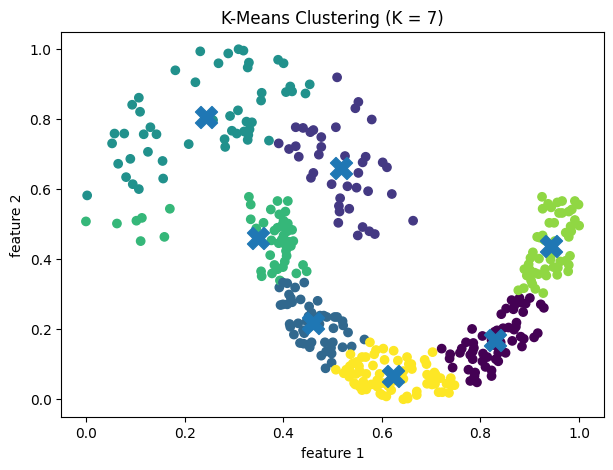

In [78]:

cluster_values = [2, 4, 6, 7]

for current_k in cluster_values:

    labels_output, centers_output, inertia_output = perform_kmeans(
        all_points,
        current_k
    )

    plt.figure(figsize=(7, 5))

    plt.scatter(
        all_points[:, 0],
        all_points[:, 1],
        c=labels_output
    )

    plt.scatter(
        centers_output[:, 0],
        centers_output[:, 1],
        marker="X",
        s=250
    )

    plt.title(
        f"K-Means Clustering (K = {current_k})"
    )

    plt.xlabel("feature 1")

    plt.ylabel("feature 2")

    plt.show()

#K vs Inertia graph

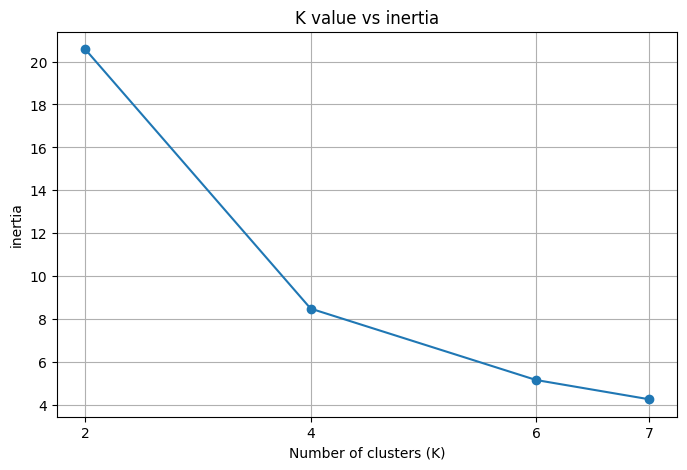

In [79]:

plt.figure(figsize=(8, 5))

plt.plot(
    cluster_values,
    inertia_values,
    marker="o"
)

plt.title(
    "K value vs inertia"
)

plt.xlabel(
    "Number of clusters (K)"
)

plt.ylabel(
    "inertia"
)

plt.xticks(cluster_values)

plt.grid(True)

plt.show()

#Final result table

In [ ]:

print("final results")

for i in range(
    len(cluster_values)
):

    print(
        f"K = {cluster_values[i]} ----> Inertia = {inertia_values[i]:.6f}"
    )

Final Results
K = 2 ----> Inertia = 20.573932
K = 4 ----> Inertia = 8.494362
K = 6 ----> Inertia = 5.169332
K = 7 ----> Inertia = 4.274690
